In [1]:
# CONFIGURATION
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
import logging
import time

from dotenv import load_dotenv
load_dotenv()

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

import numpy as np
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Paths
TRAIN_PATH = "data/training_scaled.csv"
VAL_PATH = "data/val_scaled.csv"
SCALER_PATH = "artifacts/minmax_scaler.pkl"
PREPROC_PATH = "data/nsrdb_preprocessed.csv"
DAILY_SCALER_PATH = "artifacts/daily_minmax_scaler.pkl"
DAILY_TRAIN_PATH = "data/nsrdb_daily_train.csv"
DAILY_VAL_PATH = "data/nsrdb_daily_val.csv"
DAILY_TRAIN_SCALED_PATH = "data/daily_train_scaled.csv"
DAILY_VAL_SCALED_PATH = "data/daily_val_scaled.csv"

# Sequence config
TARGET_COL = "ghi"
WINDOW_SIZE = 24  # hours
DAILY_WINDOW = 30  # days
SHORT_HORIZONS = [6, 12]
MEDIUM_HORIZONS = [7, 14]
LONG_HORIZONS = [28, 56, 84, 168, 336]
PROPHET_REGRESSORS = ["temperature", "relative_humidity", "wind_speed", "solar_zenith_angle", "surface_albedo"]

# Optuna (XGBoost tuning)
XGB_N_TRIALS = 50
XGB_CV_SPLITS = 3
XGB_MAX_ROUNDS = 500
XGB_EARLY_STOP = 20

# Keras Tuner (LSTM tuning)
LSTM_MAX_TRIALS = 20
LSTM_EPOCHS = 50
LSTM_PATIENCE = 8
LSTM_TUNER_DIR = "outputs/kt_lstm"
LSTM_PROJECT_NAME = "lstm_ghi"

# Prophet grid search
# Evaluated on the pre-split val set (no re-fitting inside the grid search)
PROPHET_PARAM_GRID = {
    "changepoint_prior_scale": [0.001, 0.01, 0.1, 0.5],
    "seasonality_prior_scale": [0.01, 0.1, 1.0, 10.0],
    "seasonality_mode": ["additive", "multiplicative"],
}

LONG_TUNE_HORIZONS = [28, 84, 336]

os.makedirs("artifacts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


In [2]:
# IMPORTS
import pandas as pd
import joblib
import itertools
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from joblib import Parallel, delayed
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(RANDOM_SEED)
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping, Callback
from keras.optimizers import Adam

from prophet import Prophet

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Optuna: {optuna.__version__}")
print(f"KerasTuner: {kt.__version__}")

I0000 00:00:1780276827.219651  281424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Optuna: 4.8.0
KerasTuner: 1.4.8


In [3]:
# LOAD DATA
train_scaled = pd.read_csv(TRAIN_PATH, index_col="datetime", parse_dates=True)
val_scaled = pd.read_csv(VAL_PATH, index_col="datetime", parse_dates=True)

# Merge train + val > full CV pool (test set is never touched)
cv_scaled = pd.concat([train_scaled, val_scaled]).sort_index()

scaler = joblib.load(SCALER_PATH)
daily_scaler = joblib.load(DAILY_SCALER_PATH)

feature_cols = cv_scaled.columns.tolist()
target_idx = feature_cols.index(TARGET_COL)

# Daily pools
daily_train_scaled = pd.read_csv(DAILY_TRAIN_SCALED_PATH, index_col="datetime", parse_dates=True)
daily_val_scaled = pd.read_csv(DAILY_VAL_SCALED_PATH, index_col="datetime", parse_dates=True)
cv_daily_scaled = pd.concat([daily_train_scaled, daily_val_scaled]).sort_index()

daily_feature_cols = cv_daily_scaled.columns.tolist()
daily_target_idx = daily_feature_cols.index(TARGET_COL)

# Unscaled data for Prophet
df_full = pd.read_csv(PREPROC_PATH, index_col="datetime", parse_dates=True)
n_full = len(df_full)
df_train_raw = df_full.iloc[: int(n_full * 0.70)]
df_val_raw = df_full.iloc[int(n_full * 0.70) : int(n_full * 0.85)]

daily_train_raw = pd.read_csv(DAILY_TRAIN_PATH, index_col="datetime", parse_dates=True)
daily_val_raw = pd.read_csv(DAILY_VAL_PATH, index_col="datetime", parse_dates=True)

print(f"Hourly CV pool: {cv_scaled.shape}")
print(f"Daily CV pool: {cv_daily_scaled.shape}")

Hourly CV pool: (74521, 17)
Daily CV pool: (3105, 15)


In [4]:
# SHARED HELPERS
def build_sequences(data, window, horizons, tgt_idx):
    X, ys = [], {h: [] for h in horizons}
    max_h = max(horizons)
    for i in range(window, len(data) - max_h + 1):
        X.append(data[i - window: i, :])
        for h in horizons:
            ys[h].append(data[i + h - 1, tgt_idx])
    return np.array(X), {h: np.array(v) for h, v in ys.items()}

def invert_ghi(scaled_vals):
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, target_idx] = scaled_vals
    return scaler.inverse_transform(dummy)[:, target_idx]

def invert_daily_ghi(scaled_vals):
    dummy = np.zeros((len(scaled_vals), daily_scaler.n_features_in_))
    dummy[:, daily_target_idx] = scaled_vals
    return daily_scaler.inverse_transform(dummy)[:, daily_target_idx]

def rmse_real(y_true_scaled, y_pred_scaled, invert_fn):
    yt = invert_fn(y_true_scaled)
    yp = invert_fn(y_pred_scaled)
    return np.sqrt(mean_squared_error(yt, yp))

def mae_real(y_true_scaled, y_pred_scaled, invert_fn):
    yt = invert_fn(y_true_scaled)
    yp = invert_fn(y_pred_scaled)
    return mean_absolute_error(yt, yp)

# Pre-build sequence arrays (used by both XGBoost and LSTM searches)
cv_arr = cv_scaled.values
X_cv, y_cv = build_sequences(cv_arr, WINDOW_SIZE, SHORT_HORIZONS, target_idx)
X_cv_flat = X_cv.reshape(X_cv.shape[0], -1)

cv_daily_arr = cv_daily_scaled.values
X_dcv, y_dcv = build_sequences(cv_daily_arr, DAILY_WINDOW, MEDIUM_HORIZONS, daily_target_idx)
X_dcv_flat = X_dcv.reshape(X_dcv.shape[0], -1)

print(f"Hourly sequences: X={X_cv.shape}")
print(f"Daily sequences: X={X_dcv.shape}")

Hourly sequences: X=(74486, 24, 17)
Daily sequences: X=(3062, 30, 15)


In [5]:
# XGBOOST TUNING - SHORT HORIZONS (6h/12h) via Optuna
# Objective: minimise mean RMSE (W/m^2) across XGB_CV_SPLITS walk-forward folds, averaged over both short horizons so a single set of params serves h=6 and h=12.
tscv_short = TimeSeriesSplit(n_splits=XGB_CV_SPLITS)

def xgb_short_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, XGB_MAX_ROUNDS, step=50),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        random_state=RANDOM_SEED,
        verbosity=0,
        early_stopping_rounds=XGB_EARLY_STOP,
        device="cuda",
        n_jobs=10,
    )

    fold_rmses = []
    for tr_idx, val_idx in tscv_short.split(X_cv_flat):
        Xtr, Xval = X_cv_flat[tr_idx], X_cv_flat[val_idx]
        horizon_rmses = []
        for h in SHORT_HORIZONS:
            ytr = y_cv[h][tr_idx]
            yval = y_cv[h][val_idx]
            m = xgb.XGBRegressor(**params)
            m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
            preds = m.predict(Xval)
            horizon_rmses.append(rmse_real(yval, preds, invert_ghi))
        fold_rmses.append(np.mean(horizon_rmses))
    return np.mean(fold_rmses)

print(f"Running Optuna XGBoost short horizon search ({XGB_N_TRIALS} trials)")
study_xgb_short = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_xgb_short.optimize(xgb_short_objective, n_trials=XGB_N_TRIALS, show_progress_bar=True)

best_xgb_short = study_xgb_short.best_params
print(f"\nBest short horizon RMSE: {study_xgb_short.best_value:.2f} W/m^2")
print(f"Best params: {best_xgb_short}")

Running Optuna XGBoost short horizon search (50 trials)


  0%|                                                                                                                                                                         | 0/50 [00:00<?, ?it/s]

sh: line 1: nvidia-smi: command not found


Best trial: 0. Best value: 99.6117:   0%|                                                                                                                                     | 0/50 [00:02<?, ?it/s]

Best trial: 0. Best value: 99.6117:   2%|██▌                                                                                                                          | 1/50 [00:02<02:02,  2.51s/it]

...

Best trial: 18. Best value: 97.3498:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 49/50 [04:12<00:06,  6.39s/it]

Best trial: 18. Best value: 97.3498:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 49/50 [04:25<00:06,  6.39s/it]

Best trial: 18. Best value: 97.3498: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [04:25<00:00,  8.35s/it]

Best trial: 18. Best value: 97.3498: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [04:25<00:00,  5.31s/it]


Best short horizon RMSE: 97.35 W/m^2
Best params: {'n_estimators': 400, 'learning_rate': 0.024364890486664268, 'max_depth': 6, 'subsample': 0.5019610230608531, 'colsample_bytree': 0.8301871575155828, 'min_child_weight': 17, 'gamma': 0.0175436357406792, 'reg_alpha': 4.540204658359108e-05, 'reg_lambda': 0.005778827393763795}


In [6]:
# XGBOOST TUNING - MEDIUM HORIZONS (7d/14d) via Optuna
tscv_daily = TimeSeriesSplit(n_splits=XGB_CV_SPLITS)

def xgb_daily_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, XGB_MAX_ROUNDS, step=50),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        random_state=RANDOM_SEED,
        verbosity=0,
        early_stopping_rounds=XGB_EARLY_STOP,
        device="cuda",
        n_jobs=10,
    )

    fold_rmses = []
    for tr_idx, val_idx in tscv_daily.split(X_dcv_flat):
        Xtr, Xval = X_dcv_flat[tr_idx], X_dcv_flat[val_idx]
        horizon_rmses = []
        for h in MEDIUM_HORIZONS:
            ytr = y_dcv[h][tr_idx]
            yval = y_dcv[h][val_idx]
            m = xgb.XGBRegressor(**params)
            m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
            preds = m.predict(Xval)
            horizon_rmses.append(rmse_real(yval, preds, invert_daily_ghi))
        fold_rmses.append(np.mean(horizon_rmses))
    return np.mean(fold_rmses)

print(f"Running Optuna XGBoost medium horizon search ({XGB_N_TRIALS} trials)")
study_xgb_daily = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_xgb_daily.optimize(xgb_daily_objective, n_trials=XGB_N_TRIALS, show_progress_bar=True)

best_xgb_daily = study_xgb_daily.best_params
print(f"\nBest medium horizon RMSE: {study_xgb_daily.best_value:.2f} Wh/m^2")
print(f"Best params: {best_xgb_daily}")

Running Optuna XGBoost medium horizon search (50 trials)


  0%|                                                                                                                                                                         | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 1451.81:   0%|                                                                                                                                     | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 1451.81:   2%|██▌                                                                                                                          | 1/50 [00:00<00:34,  1.41it/s]

Best trial: 0. Best value: 1451.81:   2%|██▌                                                                                                                          | 1/50 [00:04<00:34,  1.41it/s]

...

Best trial: 30. Best value: 1423.33:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 49/50 [02:01<00:02,  2.52s/it]

Best trial: 30. Best value: 1423.33:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌  | 49/50 [02:09<00:02,  2.52s/it]

Best trial: 30. Best value: 1423.33: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:09<00:00,  4.29s/it]

Best trial: 30. Best value: 1423.33: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [02:09<00:00,  2.60s/it]


Best medium horizon RMSE: 1423.33 Wh/m^2
Best params: {'n_estimators': 500, 'learning_rate': 0.009260348322641141, 'max_depth': 7, 'subsample': 0.6084289883407505, 'colsample_bytree': 0.8687214883097844, 'min_child_weight': 10, 'gamma': 0.35687225747397067, 'reg_alpha': 1.2855710285338536e-08, 'reg_lambda': 2.95679788526968e-07}


In [7]:
# LSTM TUNING via Keras Tuner (RandomSearch)
# Prepare train/val matrices (scaled, already split by preprocessing)
train_arr = train_scaled.values
val_arr = val_scaled.values

X_tr, y_tr = build_sequences(train_arr, WINDOW_SIZE, SHORT_HORIZONS, target_idx)
X_vl, y_vl = build_sequences(val_arr, WINDOW_SIZE, SHORT_HORIZONS, target_idx)

y_tr_mat = np.column_stack([y_tr[h] for h in SHORT_HORIZONS])
y_vl_mat = np.column_stack([y_vl[h] for h in SHORT_HORIZONS])

N_FEATURES = X_tr.shape[2]
N_OUTPUTS = len(SHORT_HORIZONS)

class EpochLogger(Callback):
    def __init__(self):
        super().__init__()
        self._t0 = None

    def on_epoch_begin(self, epoch, logs=None):
        if epoch == 0:
            self._t0 = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._t0
        print(f"epoch {epoch+1:>2} loss={logs.get('loss', float('nan')):.5f} val_loss={logs.get('val_loss', float('nan')):.5f} val_mae={logs.get('val_mae', float('nan')):.5f} {elapsed:.0f}s", flush=True,)

class LSTMHyperModel(kt.HyperModel):
    def __init__(self, window_size, n_features, n_outputs):
        self.window_size = window_size
        self.n_features = n_features
        self.n_outputs = n_outputs

    def build(self, hp):
        units_1 = hp.Int("units_1", min_value=64, max_value=256, step=64)
        units_2 = hp.Int("units_2", min_value=32, max_value=128, step=32)
        dropout = hp.Float("dropout", min_value=0.1, max_value=0.5, step=0.1)
        dense = hp.Int("dense_units", min_value=16, max_value=64, step=16)
        lr = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

        model = Sequential([
            Input(shape=(self.window_size, self.n_features)),
            LSTM(units_1, return_sequences=True, use_cudnn=False),
            Dropout(dropout),
            LSTM(units_2, return_sequences=False, use_cudnn=False),
            Dropout(dropout),
            Dense(dense, activation="relu"),
            Dense(self.n_outputs),
        ])
        model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
        return model

    def fit(self, hp, model, *args, **kwargs):
        batch_size = hp.Choice("batch_size", [32, 64, 128])
        kwargs["callbacks"] = list(kwargs.get("callbacks", [])) + [EpochLogger()]
        kwargs["verbose"] = 0  # silence Keras progress bar; EpochLogger handles output
        return model.fit(*args, batch_size=batch_size, **kwargs)

hypermodel = LSTMHyperModel(WINDOW_SIZE, N_FEATURES, N_OUTPUTS)

tuner = kt.RandomSearch(
    hypermodel,
    objective=kt.Objective("val_loss", direction="min"),
    max_trials=LSTM_MAX_TRIALS,
    seed=RANDOM_SEED,
    directory=LSTM_TUNER_DIR,
    project_name=LSTM_PROJECT_NAME,
    overwrite=True,
)

early_stop = EarlyStopping(monitor="val_loss", patience=LSTM_PATIENCE, restore_best_weights=True, verbose=0)

print(f"Keras Tuner RandomSearch ({LSTM_MAX_TRIALS} trials, up to {LSTM_EPOCHS} epochs each)")
print(f"Input shape: ({WINDOW_SIZE}, {N_FEATURES})  outputs: {N_OUTPUTS}\n")

tuner.search(X_tr, y_tr_mat, validation_data=(X_vl, y_vl_mat), epochs=LSTM_EPOCHS, callbacks=[early_stop])

best_lstm_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest LSTM hyperparameters:")
for k, v in best_lstm_hp.values.items():
    print(f"{k:<20} = {v}")

Trial 20 Complete [00h 02m 23s]
val_loss: 0.01023827027529478

Best val_loss So Far: 0.01018050592392683
Total elapsed time: 00h 28m 27s

Best LSTM hyperparameters:
units_1              = 128
units_2              = 32
dropout              = 0.2
dense_units          = 64
learning_rate        = 0.000797425773423712
batch_size           = 64


In [8]:
# PROPHET TUNING - SHORT HORIZONS (6h/12h) via parallelised grid search
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)
def prophet_val_mae(changepoint_prior_scale, seasonality_prior_scale, seasonality_mode, horizon_hours):
    train_df = df_train_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    train_df["ds"] = train_df.index
    train_df["y"] = train_df[TARGET_COL].shift(-horizon_hours)
    train_df = train_df.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    m = Prophet(
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        seasonality_mode=seasonality_mode,
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    for r in PROPHET_REGRESSORS:
        m.add_regressor(r)
    m.fit(train_df)

    val_df = df_val_raw[PROPHET_REGRESSORS].copy()
    val_df["ds"] = val_df.index

    future_target = df_full[TARGET_COL].reindex(val_df.index.shift(horizon_hours, freq="h"))
    future_target.index = val_df.index
    val_df["y"] = future_target
    val_df = val_df.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    forecast = m.predict(val_df[["ds"] + PROPHET_REGRESSORS])
    y_true = val_df["y"].values.clip(0)
    y_pred = forecast["yhat"].values.clip(0)
    return mean_absolute_error(y_true, y_pred)

grid_keys = list(PROPHET_PARAM_GRID.keys())
grid_values = list(PROPHET_PARAM_GRID.values())
combos = list(itertools.product(*grid_values))

print(f"Prophet short horizon grid search: {len(combos)} combos x {len(SHORT_HORIZONS)} horizons (parallel)")

def evaluate_short_combo(combo):
    params = dict(zip(grid_keys, combo))
    maes = [prophet_val_mae(**params, horizon_hours=h) for h in SHORT_HORIZONS]
    return {**params, "mean_mae": np.mean(maes)}

prophet_short_results = Parallel(n_jobs=10, backend="loky")(delayed(evaluate_short_combo)(combo) for combo in combos)

df_ph_short = pd.DataFrame(prophet_short_results).sort_values("mean_mae").reset_index(drop=True)
best_prophet_short = df_ph_short.iloc[0].to_dict()
print(f"\nBest short horizon Prophet params:")
print(df_ph_short.head(5).to_string(index=False))

Prophet short horizon grid search: 32 combos x 2 horizons (parallel)


20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing


20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing
20:55:34 - cmdstanpy - INFO - Chain [1] start processing


20:55:56 - cmdstanpy - INFO - Chain [1] done processing


20:55:57 - cmdstanpy - INFO - Chain [1] done processing


...

21:17:35 - cmdstanpy - INFO - Chain [1] done processing


21:17:38 - cmdstanpy - INFO - Chain [1] start processing


21:18:02 - cmdstanpy - INFO - Chain [1] done processing


21:18:33 - cmdstanpy - INFO - Chain [1] done processing



Best short horizon Prophet params:
 changepoint_prior_scale  seasonality_prior_scale seasonality_mode  mean_mae
                   0.500                     0.01         additive 86.733108
                   0.001                    10.00   multiplicative 86.815518
                   0.001                     1.00   multiplicative 86.917067
                   0.001                     0.10   multiplicative 87.044595
                   0.500                     1.00         additive 87.316113


In [9]:
# PROPHET TUNING - LONG HORIZONS via parallelised grid search
def prophet_long_val_mae(changepoint_prior_scale, seasonality_prior_scale, seasonality_mode, horizon_days):
    # Training labels 
    logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
    logging.getLogger("prophet").setLevel(logging.WARNING)
    train_df = daily_train_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    train_df["ds"] = train_df.index
    train_df["y"] = train_df[TARGET_COL].shift(-horizon_days).clip(lower=0)
    train_df = train_df.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    m = Prophet(
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        seasonality_mode=seasonality_mode,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    for r in PROPHET_REGRESSORS:
        m.add_regressor(r)
    m.fit(train_df)

    daily_full = pd.concat([daily_train_raw, daily_val_raw]).sort_index()
    val_df = daily_val_raw[PROPHET_REGRESSORS].copy()
    val_df["ds"] = val_df.index

    future_target = daily_full[TARGET_COL].reindex(val_df.index.shift(horizon_days, freq="D"))
    future_target.index = val_df.index
    val_df["y"] = future_target.clip(lower=0)
    val_df = val_df.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    forecast = m.predict(val_df[["ds"] + PROPHET_REGRESSORS])
    y_true = val_df["y"].values
    y_pred = forecast["yhat"].values.clip(0)
    return mean_absolute_error(y_true, y_pred)

print(f"Prophet long horizon grid search: {len(combos)} combos x {len(LONG_TUNE_HORIZONS)} horizons {LONG_TUNE_HORIZONS} (parallel)")

def evaluate_long_combo(combo):
    params = dict(zip(grid_keys, combo))
    maes = [prophet_long_val_mae(**params, horizon_days=h) for h in LONG_TUNE_HORIZONS]
    return {**params, "mean_mae": np.mean(maes)}

prophet_long_results = Parallel(n_jobs=10, backend="loky")(delayed(evaluate_long_combo)(combo) for combo in combos)

df_ph_long = pd.DataFrame(prophet_long_results).sort_values("mean_mae").reset_index(drop=True)
best_prophet_long = df_ph_long.iloc[0].to_dict()
print(f"\nBest long horizon Prophet params:")
print(df_ph_long.head(5).to_string(index=False))

Prophet long horizon grid search: 32 combos x 3 horizons [28, 84, 336] (parallel)


21:18:36 - cmdstanpy - INFO - Chain [1] start processing
21:18:36 - cmdstanpy - INFO - Chain [1] start processing
21:18:36 - cmdstanpy - INFO - Chain [1] done processing
21:18:36 - cmdstanpy - INFO - Chain [1] done processing



Best long horizon Prophet params:
 changepoint_prior_scale  seasonality_prior_scale seasonality_mode    mean_mae
                     0.1                    10.00         additive 1122.778265
                     0.1                     1.00         additive 1124.222683
                     0.1                     0.10         additive 1125.231198
                     0.1                     0.01         additive 1149.161928
                     0.1                    10.00   multiplicative 1150.136349


In [10]:
# RETRAIN BEST MODELS ON FULL TRAIN SPLIT

# XGBoost short horizons
xgb_tuned_models = {}
X_tr_seq, y_tr_seq = build_sequences(train_scaled.values, WINDOW_SIZE, SHORT_HORIZONS, target_idx)
X_vl_seq, y_vl_seq = build_sequences(val_scaled.values, WINDOW_SIZE, SHORT_HORIZONS, target_idx)

X_tr_2d = X_tr_seq.reshape(X_tr_seq.shape[0], -1)
X_vl_2d = X_vl_seq.reshape(X_vl_seq.shape[0], -1)

for h in SHORT_HORIZONS:
    m = xgb.XGBRegressor(
        **best_xgb_short,
        random_state=RANDOM_SEED,
        verbosity=0,
        early_stopping_rounds=XGB_EARLY_STOP,
        device="cuda",
        n_jobs=10,
    )
    m.fit(X_tr_2d, y_tr_seq[h], eval_set=[(X_vl_2d, y_vl_seq[h])], verbose=False)

    # Freeze best_iteration so predict() is deterministic across xgb versions
    m.set_params(n_estimators=m.best_iteration)
    m.early_stopping_rounds = None  # no eval set available at inference time

    xgb_tuned_models[h] = m
    print(f"XGBoost short h={h}h retrained - best_iteration={m.best_iteration}")

joblib.dump(xgb_tuned_models, "artifacts/xgb_tuned_models.pkl")
print("Saved to artifacts/xgb_tuned_models.pkl")

# XGBoost medium horizons
xgb_daily_tuned_models = {}
X_dtr_seq, y_dtr_seq = build_sequences(daily_train_scaled.values, DAILY_WINDOW, MEDIUM_HORIZONS, daily_target_idx)
X_dvl_seq, y_dvl_seq = build_sequences(daily_val_scaled.values, DAILY_WINDOW, MEDIUM_HORIZONS, daily_target_idx)

X_dtr_2d = X_dtr_seq.reshape(X_dtr_seq.shape[0], -1)
X_dvl_2d = X_dvl_seq.reshape(X_dvl_seq.shape[0], -1)

for h in MEDIUM_HORIZONS:
    m = xgb.XGBRegressor(
        **best_xgb_daily,
        random_state=RANDOM_SEED,
        verbosity=0,
        early_stopping_rounds=XGB_EARLY_STOP,
        device="cuda",
        n_jobs=10,
    )
    m.fit(X_dtr_2d, y_dtr_seq[h], eval_set=[(X_dvl_2d, y_dvl_seq[h])], verbose=False)

    # Freeze best_iteration
    m.set_params(n_estimators=m.best_iteration)
    m.early_stopping_rounds = None

    xgb_daily_tuned_models[h] = m
    print(f"XGBoost daily h={h}d retrained - best_iteration={m.best_iteration}")

joblib.dump(xgb_daily_tuned_models, "artifacts/xgb_daily_tuned_models.pkl")
print("Saved to artifacts/xgb_daily_tuned_models.pkl")

XGBoost short h=6h retrained - best_iteration=215


XGBoost short h=12h retrained - best_iteration=156
Saved to artifacts/xgb_tuned_models.pkl


XGBoost daily h=7d retrained - best_iteration=342


XGBoost daily h=14d retrained - best_iteration=415
Saved to artifacts/xgb_daily_tuned_models.pkl


In [11]:
# LSTM: retrain best trial architecture on train split, validate on val split
print("Retraining best LSTM architecture")

best_lstm_model = tuner.hypermodel.build(best_lstm_hp)

early_stop_final = EarlyStopping(monitor="val_loss", patience=LSTM_PATIENCE + 2, restore_best_weights=True, verbose=1,)

history_tuned = best_lstm_model.fit(
    X_tr, y_tr_mat,
    validation_data=(X_vl, y_vl_mat),
    epochs=100,
    batch_size=best_lstm_hp.values.get("batch_size", 64),
    callbacks=[early_stop_final],
    verbose=1,
)

best_lstm_model.save("artifacts/lstm_tuned.keras")
print(f"Saved to artifacts/lstm_tuned.keras")
print(f"Best val_loss: {min(history_tuned.history['val_loss']):.6f}")

Retraining best LSTM architecture
Epoch 1/100


  1/959 ━━━━━━━━━━━━━━━━━━━━ 31:50 2s/step - loss: 0.0807 - mae: 0.1775

 14/959 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0570 - mae: 0.1746  

 27/959 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0497 - mae: 0.1644

 40/959 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0447 - mae: 0.1559

...

955/959 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - mae: 0.0486

959/959 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0084 - mae: 0.0487 - val_loss: 0.0111 - val_mae: 0.0569


Epoch 19: early stopping


Restoring model weights from the end of the best epoch: 9.


Saved to artifacts/lstm_tuned.keras
Best val_loss: 0.010446


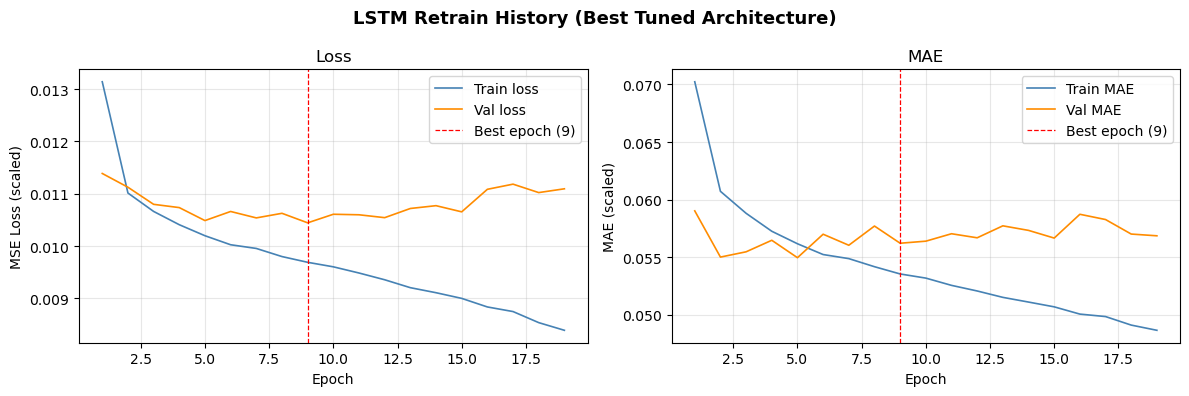

Plot saved to outputs/lstm_tuned_history.png


In [12]:
# PLOT: LSTM RETRAIN HISTORY (best Keras Tuner architecture)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LSTM Retrain History (Best Tuned Architecture)", fontsize=13, fontweight="bold")

epochs  = range(1, len(history_tuned.history["loss"]) + 1)
best_ep = int(np.argmin(history_tuned.history["val_loss"])) + 1

# Loss
ax = axes[0]
ax.plot(epochs, history_tuned.history["loss"], color="steelblue", linewidth=1.2, label="Train loss")
ax.plot(epochs, history_tuned.history["val_loss"], color="darkorange", linewidth=1.2, label="Val loss")
ax.axvline(best_ep, color="red", linewidth=0.9, linestyle="--", label=f"Best epoch ({best_ep})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("Loss")
ax.legend()
ax.grid(alpha=0.3)

# MAE
ax = axes[1]
ax.plot(epochs, history_tuned.history["mae"], color="steelblue", linewidth=1.2, label="Train MAE")
ax.plot(epochs, history_tuned.history["val_mae"], color="darkorange", linewidth=1.2, label="Val MAE")
ax.axvline(best_ep, color="red", linewidth=0.9, linestyle="--", label=f"Best epoch ({best_ep})")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (scaled)")
ax.set_title("MAE")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/lstm_tuned_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/lstm_tuned_history.png")

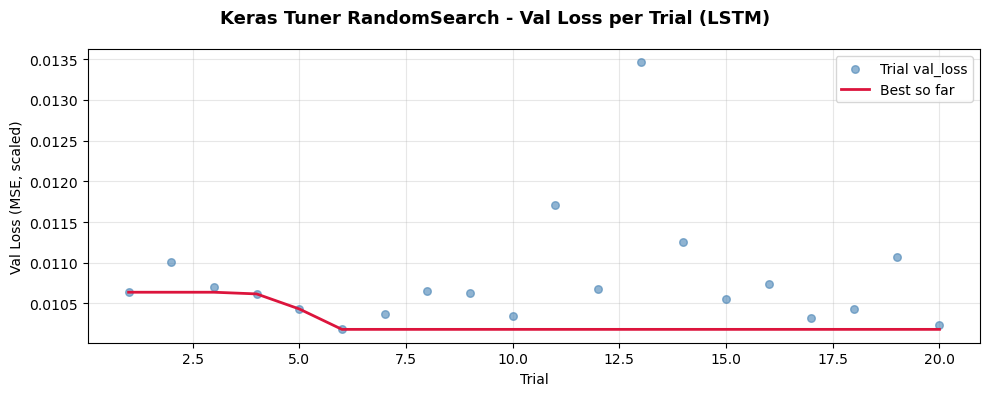

Plot saved to outputs/kt_lstm_trial_history.png


In [13]:
# PLOT: KERAS TUNER TRIAL HISTORY
# Val loss for every trial. Red line marks the best trial.
# Mirrors the Optuna optimisation history plots for XGBoost.
trial_vals = []
for trial in tuner.oracle.get_best_trials(num_trials=LSTM_MAX_TRIALS):
    score = trial.score
    if score is not None:
        trial_vals.append(score)

# Oracle returns best-first; re-sort by trial number for a chronological view
all_trials = sorted(
    [t for t in tuner.oracle.trials.values() if t.score is not None],
    key=lambda t: t.trial_id
)
trial_numbers = list(range(1, len(all_trials) + 1))
trial_scores = [t.score for t in all_trials]
best_so_far = list(np.minimum.accumulate(trial_scores))

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Keras Tuner RandomSearch - Val Loss per Trial (LSTM)", fontsize=13, fontweight="bold")

ax.scatter(trial_numbers, trial_scores, alpha=0.6, s=30, color="steelblue", label="Trial val_loss", zorder=2)
ax.plot(trial_numbers, best_so_far, color="crimson", linewidth=2, label="Best so far", zorder=3)
ax.set_xlabel("Trial")
ax.set_ylabel("Val Loss (MSE, scaled)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/kt_lstm_trial_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/kt_lstm_trial_history.png")

In [14]:
# Prophet short horizons: retrain best config
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

prophet_tuned_models = {}
cps = best_prophet_short["changepoint_prior_scale"]
sps = best_prophet_short["seasonality_prior_scale"]
mode = best_prophet_short["seasonality_mode"]

for h in SHORT_HORIZONS:
    train_df = df_train_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    train_df["ds"] = train_df.index
    train_df["y"] = train_df[TARGET_COL].shift(-h)
    train_df = train_df.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    pm = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        seasonality_mode=mode,
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    for r in PROPHET_REGRESSORS:
        pm.add_regressor(r)
    pm.fit(train_df)
    prophet_tuned_models[h] = pm
    joblib.dump(pm, f"artifacts/prophet_tuned_h{h}.pkl")
    print(f"Prophet short h={h}h retrained & saved.")

# Prophet long horizons: retrain best config
prophet_long_tuned_models = {}
cps_l = best_prophet_long["changepoint_prior_scale"]
sps_l = best_prophet_long["seasonality_prior_scale"]
mode_l = best_prophet_long["seasonality_mode"]

for h in LONG_HORIZONS:
    train_df = daily_train_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    train_df["ds"] = train_df.index
    train_df["y"] = train_df[TARGET_COL].shift(-h).clip(lower=0)
    train_df = train_df.dropna()[["ds", "y"] + PROPHET_REGRESSORS]
    
    pm = Prophet(
        changepoint_prior_scale=cps_l,
        seasonality_prior_scale=sps_l,
        seasonality_mode=mode_l,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    for r in PROPHET_REGRESSORS:
        pm.add_regressor(r)
    pm.fit(train_df)
    prophet_long_tuned_models[h] = pm
    joblib.dump(pm, f"artifacts/prophet_long_tuned_h{h}d.pkl")
    weeks = h // 7
    print(f"Prophet long h={h}d ({weeks}w) retrained & saved.")

21:20:06 - cmdstanpy - INFO - Chain [1] start processing


21:20:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet short h=6h retrained & saved.


21:20:24 - cmdstanpy - INFO - Chain [1] start processing


21:20:52 - cmdstanpy - INFO - Chain [1] done processing


...

Prophet long h=56d (8w) retrained & saved.
Prophet long h=84d (12w) retrained & saved.


21:20:53 - cmdstanpy - INFO - Chain [1] done processing


21:20:53 - cmdstanpy - INFO - Chain [1] start processing


21:20:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet long h=168d (24w) retrained & saved.
Prophet long h=336d (48w) retrained & saved.


In [15]:
# SUMMARY - best params table + optimisation curve plots
# Note: baseline values marked "-" reflect that XGBoost's internal defaults for those params vary by tree method
# They are omitted intentionally rather than risk misrepresenting the comparison.
baseline_xgb = dict(n_estimators=500, learning_rate=0.05, max_depth=6, subsample="-", colsample_bytree="-", min_child_weight="-", gamma="-", reg_alpha="-", reg_lambda="-")

rows = []
for key in ["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "min_child_weight", "gamma", "reg_alpha", "reg_lambda"]:
    rows.append({
        "param": key,
        "baseline": baseline_xgb[key],
        "tuned_short": best_xgb_short.get(key, "-"),
        "tuned_medium": best_xgb_daily.get(key, "-"),
    })

df_xgb_summary = pd.DataFrame(rows)
print("XGBoost parameter comparison (baseline vs Optuna best)")
print(df_xgb_summary.to_string(index=False))

print("\nLSTM hyperparameter comparison (baseline vs Keras Tuner best)")
lstm_baseline = dict(units_1=128, units_2=64, dropout=0.2, dense_units=32, learning_rate=0.001)
for key, base_val in lstm_baseline.items():
    tuned_val = best_lstm_hp.values.get(key, "-")
    print(f"{key:<20} baseline={base_val:<10} tuned={tuned_val}")

print("\nProphet parameter comparison (baseline vs grid-search best)")
prophet_baseline = dict(changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, seasonality_mode="additive")
for key, base_val in prophet_baseline.items():
    short_v = best_prophet_short.get(key, "-")
    long_v = best_prophet_long.get(key, "-")
    print(f"{key:<30} baseline={str(base_val):<14} short={str(short_v):<14} long={long_v}")

XGBoost parameter comparison (baseline vs Optuna best)
           param baseline  tuned_short  tuned_medium
    n_estimators      500   400.000000  5.000000e+02
   learning_rate     0.05     0.024365  9.260348e-03
       max_depth        6     6.000000  7.000000e+00
       subsample        -     0.501961  6.084290e-01
colsample_bytree        -     0.830187  8.687215e-01
min_child_weight        -    17.000000  1.000000e+01
           gamma        -     0.017544  3.568723e-01
       reg_alpha        -     0.000045  1.285571e-08
      reg_lambda        -     0.005779  2.956798e-07

LSTM hyperparameter comparison (baseline vs Keras Tuner best)
units_1              baseline=128        tuned=128
units_2              baseline=64         tuned=32
dropout              baseline=0.2        tuned=0.2
dense_units          baseline=32         tuned=64
learning_rate        baseline=0.001      tuned=0.000797425773423712

Prophet parameter comparison (baseline vs grid-search best)
changepoint_prior_sca

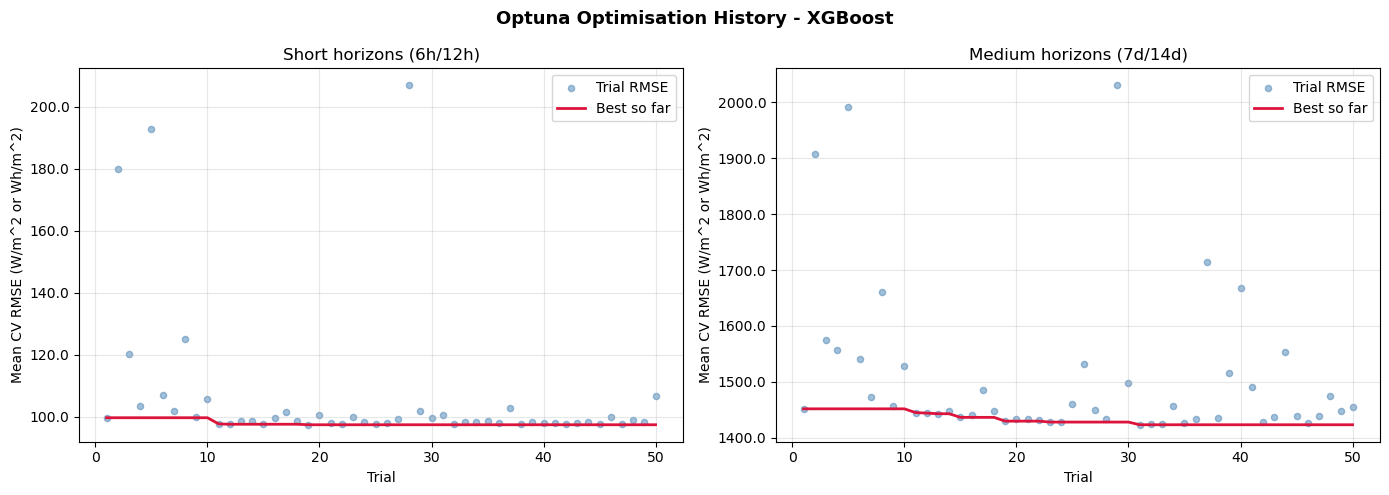

Plot saved to outputs/optuna_xgb_history.png


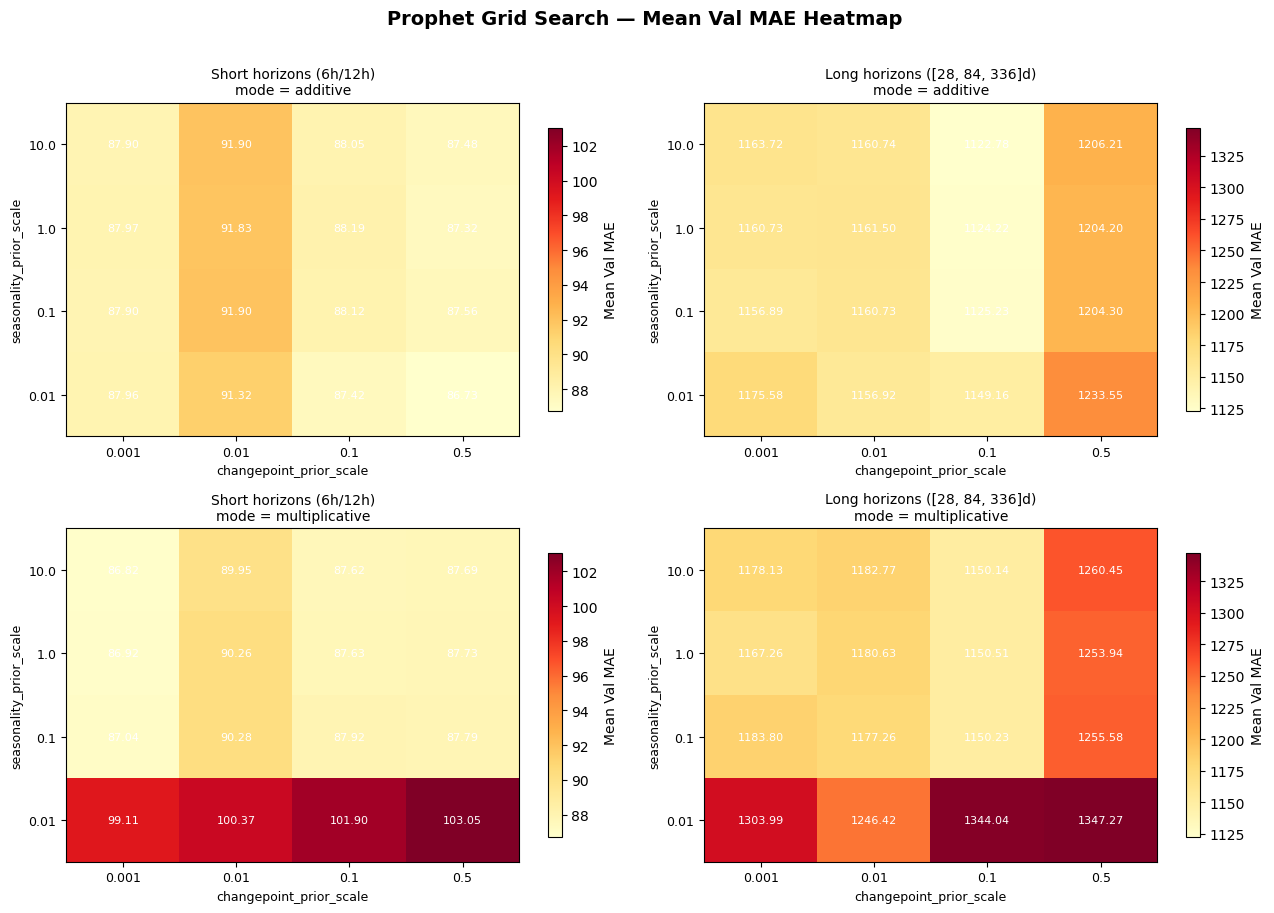

Saved to outputs/prophet_grid_search_heatmap.png


In [16]:
# Optuna optimisation history plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optuna Optimisation History - XGBoost", fontsize=13, fontweight="bold")

for ax, study, title in zip(axes, [study_xgb_short, study_xgb_daily], ["Short horizons (6h/12h)", "Medium horizons (7d/14d)"],):
    values = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(values)
    ax.scatter(range(1, len(values) + 1), values, alpha=0.5, s=20, color="steelblue", label="Trial RMSE")
    ax.plot(range(1, len(best_so_far) + 1), best_so_far, color="crimson", linewidth=2, label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("Mean CV RMSE (W/m^2 or Wh/m^2)")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

plt.tight_layout()
plt.savefig("outputs/optuna_xgb_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/optuna_xgb_history.png")

# Prophet grid-search MAE Heatmap
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Prophet Grid Search — Mean Val MAE Heatmap", fontsize=14, fontweight="bold", y=1.01)

horizon_labels = [("Short horizons (6h/12h)", df_ph_short), (f"Long horizons ({LONG_TUNE_HORIZONS}d)", df_ph_long),]
modes = ["additive", "multiplicative"]

for col, (horizon_title, df_res) in enumerate(horizon_labels):
    for row, mode_val in enumerate(modes):
        ax = axes[row][col]
        sub = df_res[df_res["seasonality_mode"] == mode_val].copy()

        pivot = sub.pivot(index="seasonality_prior_scale", columns="changepoint_prior_scale", values="mean_mae",)
        pivot = pivot.sort_index(ascending=False)  # largest sps at top

        vmin, vmax = df_res["mean_mae"].min(), df_res["mean_mae"].max()
        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=vmin, vmax=vmax)

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([str(v) for v in pivot.columns], fontsize=9)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([str(v) for v in pivot.index], fontsize=9)
        ax.set_xlabel("changepoint_prior_scale", fontsize=9)
        ax.set_ylabel("seasonality_prior_scale", fontsize=9)
        ax.set_title(f"{horizon_title}\nmode = {mode_val}", fontsize=10)

        # Annotate each cell with its MAE value
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=8, color="black" if val < vmax * 0.75 else "white")

        plt.colorbar(im, ax=ax, shrink=0.85, label="Mean Val MAE")

plt.tight_layout()
plt.savefig("outputs/prophet_grid_search_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/prophet_grid_search_heatmap.png")

In [17]:
# Save tuning results to CSV + best-params dict
best_params_all = {
    "xgb_short": best_xgb_short,
    "xgb_medium": best_xgb_daily,
    "lstm": dict(best_lstm_hp.values),
    "prophet_short": {k: v for k, v in best_prophet_short.items() if k != "mean_mae"},
    "prophet_long": {k: v for k, v in best_prophet_long.items() if k != "mean_mae"},
}
joblib.dump(best_params_all, "artifacts/best_hyperparams.pkl")
print("Best hyperparameters saved to artifacts/best_hyperparams.pkl")

# Optuna trial histories
short_cols = ["number", "value"] + [c for c in study_xgb_short.trials_dataframe().columns if c.startswith("params_")]
study_xgb_short.trials_dataframe()[short_cols].to_csv("outputs/optuna_xgb_short_trials.csv", index=False)

daily_cols = ["number", "value"] + [c for c in study_xgb_daily.trials_dataframe().columns if c.startswith("params_")]
study_xgb_daily.trials_dataframe()[daily_cols].to_csv("outputs/optuna_xgb_daily_trials.csv", index=False)

# Prophet results
df_ph_short.to_csv("outputs/prophet_short_grid_results.csv", index=False)
df_ph_long.to_csv("outputs/prophet_long_grid_results.csv", index=False)

print("\nTuned artifacts")
tuned_files = (
    ["artifacts/xgb_tuned_models.pkl", "artifacts/xgb_daily_tuned_models.pkl", "artifacts/lstm_tuned.keras", "artifacts/best_hyperparams.pkl"]
    + [f"artifacts/prophet_tuned_h{h}.pkl" for h in SHORT_HORIZONS] + [f"artifacts/prophet_long_tuned_h{h}d.pkl" for h in LONG_HORIZONS]
)

for f in tuned_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"{f} ({size_kb:.1f} KB)")
    else:
        print(f"{f} < NOT FOUND")

print("\nHyperparameter tuning complete.")

Best hyperparameters saved to artifacts/best_hyperparams.pkl

Tuned artifacts
artifacts/xgb_tuned_models.pkl (1528.7 KB)
artifacts/xgb_daily_tuned_models.pkl (893.6 KB)
artifacts/lstm_tuned.keras (1184.7 KB)
artifacts/best_hyperparams.pkl (0.6 KB)
artifacts/prophet_tuned_h6.pkl (7843.7 KB)
artifacts/prophet_tuned_h12.pkl (7842.9 KB)
artifacts/prophet_long_tuned_h28d.pkl (330.1 KB)
artifacts/prophet_long_tuned_h56d.pkl (326.5 KB)
artifacts/prophet_long_tuned_h84d.pkl (323.0 KB)
artifacts/prophet_long_tuned_h168d.pkl (312.4 KB)
artifacts/prophet_long_tuned_h336d.pkl (290.8 KB)

Hyperparameter tuning complete.
